In [ ]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Load dataset
df = pd.read_excel("refugeedata.xlsx", sheet_name='Sheet1', skiprows=10)
df.head()


,1977,-,19946
0,1978,-,36507.0
1,1979,-,111363.0
2,1980,231700,207116.0
3,1981,217000,159252.0
4,1982,140000,98096.0


In [ ]:
# Rename columns
df.columns = ['Year', 'Ceiling', 'Actual_Resettled']

# Clean and convert columns
df = df[pd.to_numeric(df['Year'], errors='coerce').notnull()]
df['Year'] = df['Year'].astype(int)
df['Ceiling'] = pd.to_numeric(df['Ceiling'], errors='coerce')
df['Actual_Resettled'] = pd.to_numeric(df['Actual_Resettled'], errors='coerce')
df = df.dropna()

# Show cleaned data
df.head()


<ipython-input-4-646069cebbf4>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)
<ipython-input-4-646069cebbf4>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ceiling'] = pd.to_numeric(df['Ceiling'], errors='coerce')
<ipython-input-4-646069cebbf4>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

,Year,Ceiling,Actual_Resettled
2,1980,231700.0,207116.0
3,1981,217000.0,159252.0
4,1982,140000.0,98096.0
5,1983,90000.0,61218.0
6,1984,72000.0,70393.0


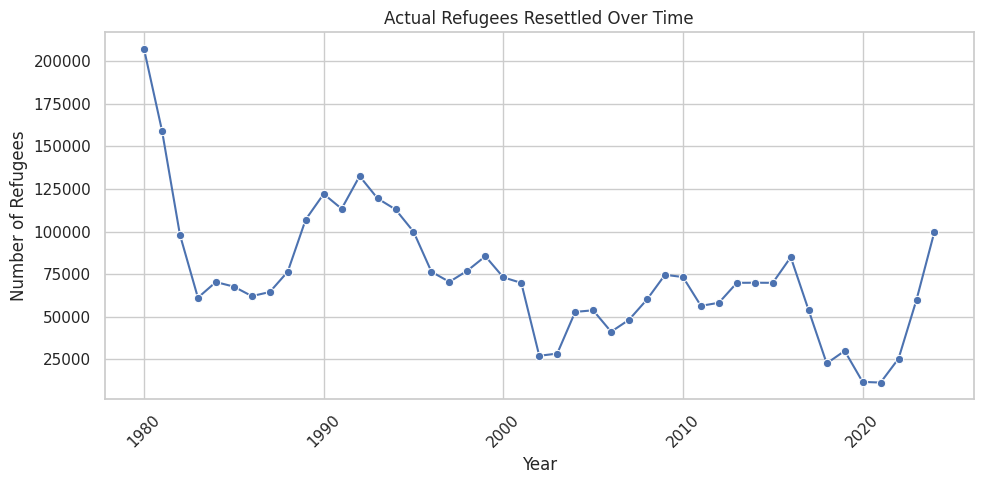

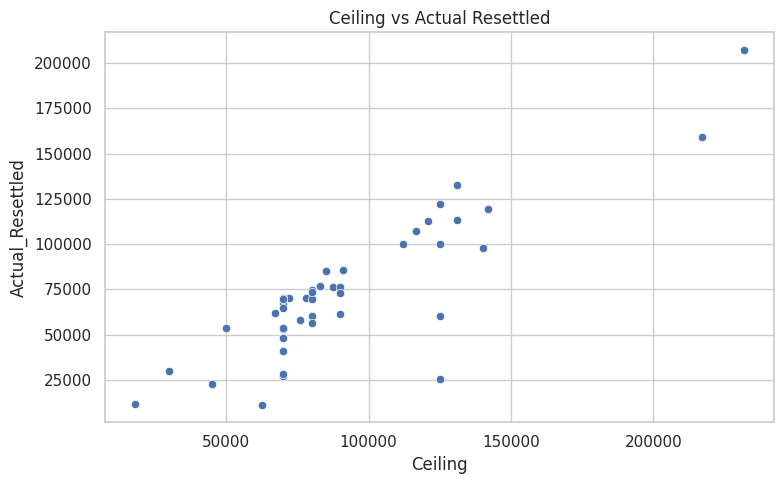

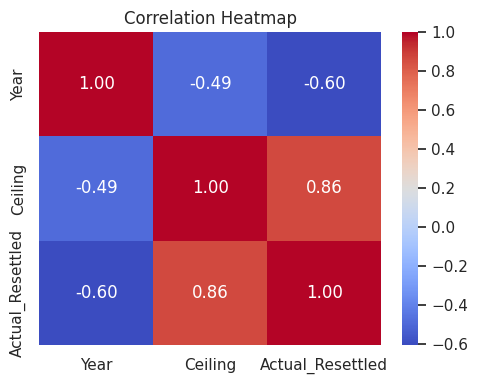

In [ ]:
sns.set(style="whitegrid")

# Line plot of resettlement over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='Actual_Resettled', marker='o')
plt.title('Actual Refugees Resettled Over Time')
plt.ylabel('Number of Refugees')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter plot of Ceiling vs Actual
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Ceiling', y='Actual_Resettled')
plt.title('Ceiling vs Actual Resettled')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(df[['Year', 'Ceiling', 'Actual_Resettled']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
# Define features and target
X = df[['Year', 'Ceiling']]
y = df['Actual_Resettled']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"MSE: {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")


Linear Regression Results:
MSE: 341130611.90
R² Score: 0.6729


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 7882298368.0000 - val_loss: 5387423744.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - loss: 7882293248.0000 - val_loss: 5387419648.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 7882287616.0000 - val_loss: 5387416064.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 7882282496.0000 - val_loss: 5387412480.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 7882276864.0000 - val_loss: 5387407360.0000
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 7882271232.0000 - val_loss: 5387403776.0000
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 7882265600.0000 - val_loss: 5387400192.0000
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 7882259968.0000 - val_loss: 5387395584.0000
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 7882254848.0000 - val_loss: 5387391488.0000
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 7882248704.0000 - val_loss: 5

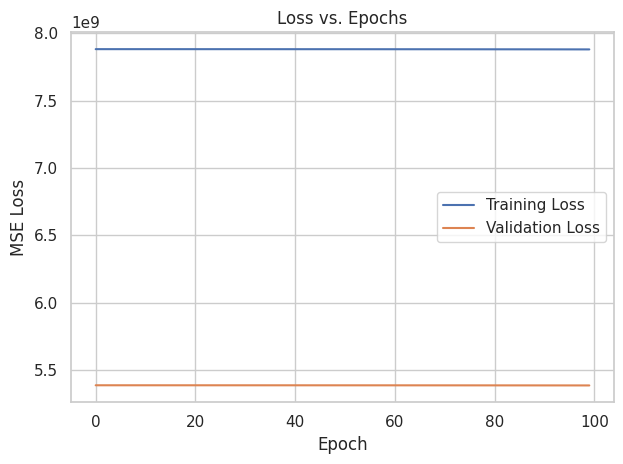

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model ---
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# --- Training ---
history = model.fit(X_train_scaled, y_train,
                    epochs=100,
                    validation_split=0.2,
                    verbose=1)

#Evaluation
y_pred = model.predict(X_test_scaled).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test R² Score: {r2:.4f}")

#Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train the decision tree
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)  # You can tune max_depth
tree_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_tree = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results:")
print(f"MSE: {mse_tree:.2f}")
print(f"R² Score: {r2_tree:.4f}")


Decision Tree Regressor Results:
MSE: 232564734.61
R² Score: 0.7770


In [ ]:
# Cross validation for Linear Regression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

lr_model = LinearRegression()

r2_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')
mse_scores = -cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_squared_error')

print("Linear Regression - Cross-Validation Results:")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average MSE: {np.mean(mse_scores):.2f}")


Linear Regression - Cross-Validation Results:
Average R² Score: -0.3041
Average MSE: 477829655.65


In [ ]:
# Cross validation for Decision Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)

r2_scores = cross_val_score(tree_model, X, y, cv=5, scoring='r2')
mse_scores = -cross_val_score(tree_model, X, y, cv=5, scoring='neg_mean_squared_error')

print("Decision Tree - Cross-Validation Results:")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average MSE: {np.mean(mse_scores):.2f}")


Decision Tree - Cross-Validation Results:
Average R² Score: -1.2801
Average MSE: 1207414111.75


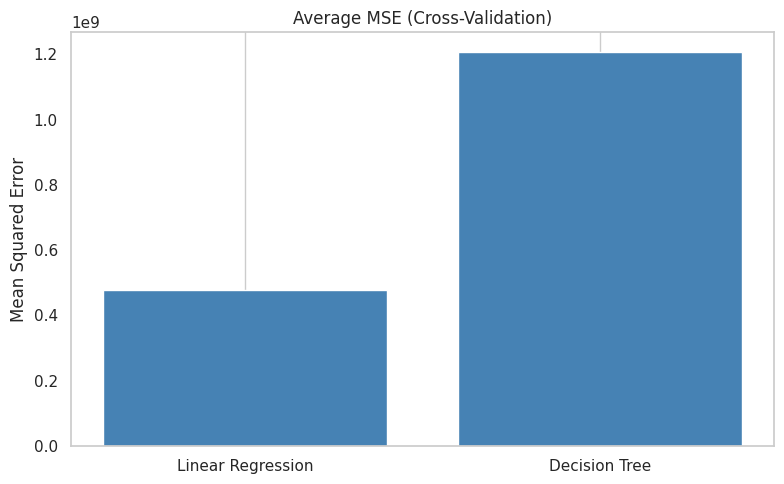

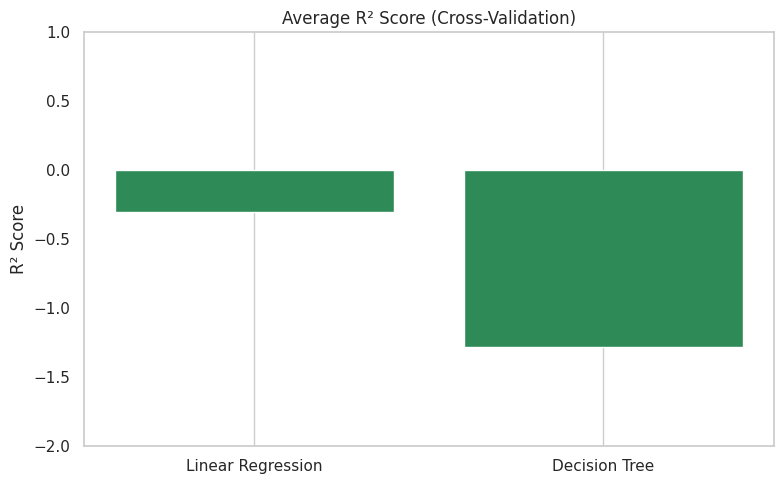

In [36]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree']
avg_mse = [477829655.65, 1207414111.75]
avg_r2 = [-0.3041, -1.2801]

# Plot MSE
plt.figure(figsize=(8, 5))
plt.bar(models, avg_mse, color='steelblue')
plt.title('Average MSE (Cross-Validation)')
plt.ylabel('Mean Squared Error')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plot R² Score
plt.figure(figsize=(8, 5))
plt.bar(models, avg_r2, color='seagreen')
plt.title('Average R² Score (Cross-Validation)')
plt.ylabel('R² Score')
plt.ylim(-2, 1)  # Adjust y-axis for negative scores
plt.grid(axis='y')
plt.tight_layout()
plt.show()
